In [2]:
import numpy as np
import pathlib
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpim
import tensorflow as tf
from tensorflow.keras import layers, models



In [3]:
# variables to use
IMAGE_SIZE=256
BATCH_SIZE=32
CHANNELS=3

In [4]:
data_dir = pathlib.Path("poultry_diseases")

dataset = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    shuffle=True,
    seed=123,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)


Found 6812 files belonging to 4 classes.


In [5]:
class_names=dataset.class_names

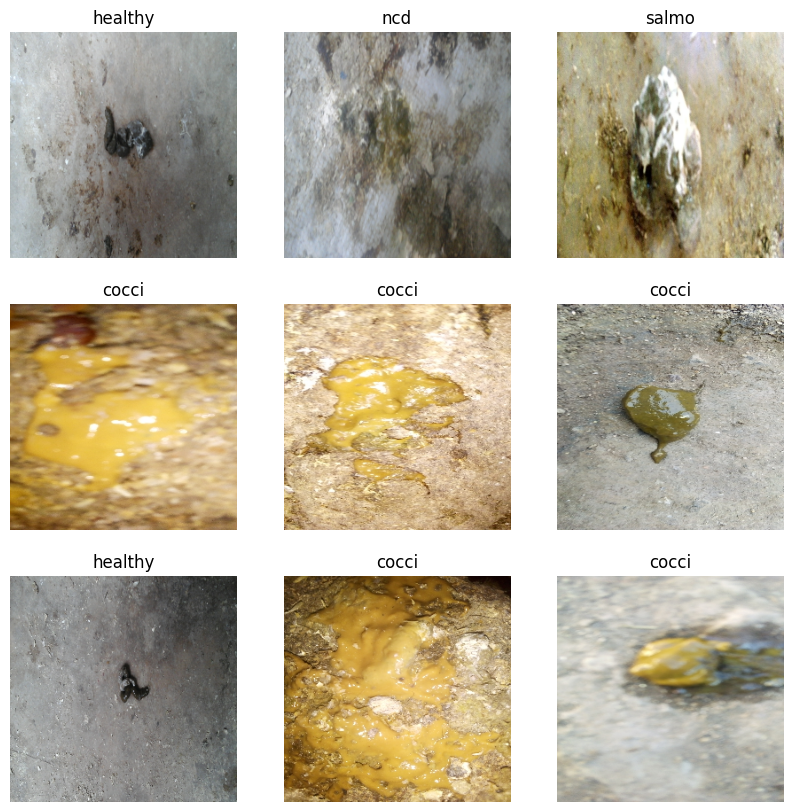

In [6]:
plt.figure(figsize=(10,10))
for img,label in dataset.take(1):
    for i in range(9):
        ax=plt.subplot(3,3,i+1)
        plt.imshow(img[i].numpy().astype('uint8'))
        plt.title(class_names[label[i].numpy()])
        plt.axis("off")

In [7]:
def data_split(data,train_size=0.8,validation_size=0.1,test_size=0.1,shuffle=True):
    if shuffle:
        data.shuffle(1000,seed=0)
    train_set=data.take(int(len(data)*train_size))
    val_set=data.skip(len(train_set)).take(int(len(data)*validation_size))
    test_set=data.skip(len(train_set)+len(val_set))
    return train_set, val_set, test_set

In [8]:
train_set, val_set, test_set= data_split(dataset)

In [9]:
train= train_set.cache().shuffle(100).prefetch(buffer_size=tf.data.AUTOTUNE)
valid= val_set.cache().shuffle(100).prefetch(buffer_size=tf.data.AUTOTUNE)
test= test_set.cache().shuffle(100).prefetch(buffer_size=tf.data.AUTOTUNE)

In [11]:
img_processor = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1./255)
])


In [13]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.5)
])

In [14]:
input_shape=(BATCH_SIZE,IMAGE_SIZE,IMAGE_SIZE,CHANNELS)

In [15]:
CNN=models.Sequential([
    img_processor,
    data_augmentation,
    layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu',input_shape=input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(len(class_names),activation='softmax')
])
CNN.build(input_shape)

d:\Users\DEBJIT   DAS\Farm Management\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
CNN.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 60, 60, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 30, 30, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (32, 28, 28, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (32, 12, 12, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (32, 6, 6, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (32, 4, 4, 64)         │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (32, 2, 2, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 128)              │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 4)                │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 348,100 (1.33 MB)

 Trainable params: 348,100 (1.33 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
CNN.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
            loss = 'sparse_categorical_crossentropy',
            metrics=['accuracy'])

In [18]:
training_his=CNN.fit(train,epochs=10,validation_data=valid,batch_size=BATCH_SIZE)

Epoch 1/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 124s 677ms/step - accuracy: 0.6632 - loss: 0.7734 - val_accuracy: 0.8497 - val_loss: 0.5346
Epoch 2/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 99s 584ms/step - accuracy: 0.8040 - loss: 0.5465 - val_accuracy: 0.8646 - val_loss: 0.4718
Epoch 3/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 151s 888ms/step - accuracy: 0.8485 - loss: 0.4533 - val_accuracy: 0.8884 - val_loss: 0.3763
Epoch 4/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 99s 584ms/step - accuracy: 0.8676 - loss: 0.3998 - val_accuracy: 0.8958 - val_loss: 0.3339
Epoch 5/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.8820 - loss: 0.3530 - val_accuracy: 0.8973 - val_loss: 0.3387
Epoch 6/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - accuracy: 0.8842 - loss: 0.3309 - val_accuracy: 0.8973 - val_loss: 0.3293
Epoch 7/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.8794 - loss: 0.3368 - val_accuracy: 0.8914 - val_loss: 0.3153
Epoch 8/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 244s 1s/step - accuracy: 0.8932 - loss: 0.2807 

In [19]:
scores= CNN.evaluate(train)

170/170 ━━━━━━━━━━━━━━━━━━━━ 53s 310ms/step - accuracy: 0.9278 - loss: 0.1959


In [20]:
scores

[0.19592854380607605, 0.9277573823928833]

In [21]:
training_his.params

{'verbose': 'auto', 'epochs': 10, 'steps': 170}

In [22]:
training_his.history


{'accuracy': [0.6632353067398071,
  0.8040441274642944,
  0.8485293984413147,
  0.8676470518112183,
  0.8819853067398071,
  0.8841911554336548,
  0.8794117569923401,
  0.893198549747467,
  0.8988970518112183,
  0.914338231086731],
 'loss': [0.7733920812606812,
  0.5464877486228943,
  0.4533331096172333,
  0.39976751804351807,
  0.35296204686164856,
  0.3308950662612915,
  0.33680447936058044,
  0.28066956996917725,
  0.26900631189346313,
  0.2328440248966217],
 'val_accuracy': [0.8497023582458496,
  0.8645833134651184,
  0.8883928656578064,
  0.8958333134651184,
  0.8973214030265808,
  0.8973214030265808,
  0.8913690447807312,
  0.9166666865348816,
  0.9017857313156128,
  0.9166666865348816],
 'val_loss': [0.5345577001571655,
  0.4717811942100525,
  0.37634286284446716,
  0.3339391350746155,
  0.3386772572994232,
  0.3292790651321411,
  0.31529173254966736,
  0.27473944425582886,
  0.3091762959957123,
  0.27510324120521545]}

In [23]:
for key,values in training_his.history.items():
    training_loss=training_his.history['loss']
    training_accuracy=training_his.history['accuracy']
    validation_loss=training_his.history['val_loss']
    validation_accuracy=training_his.history['val_accuracy']

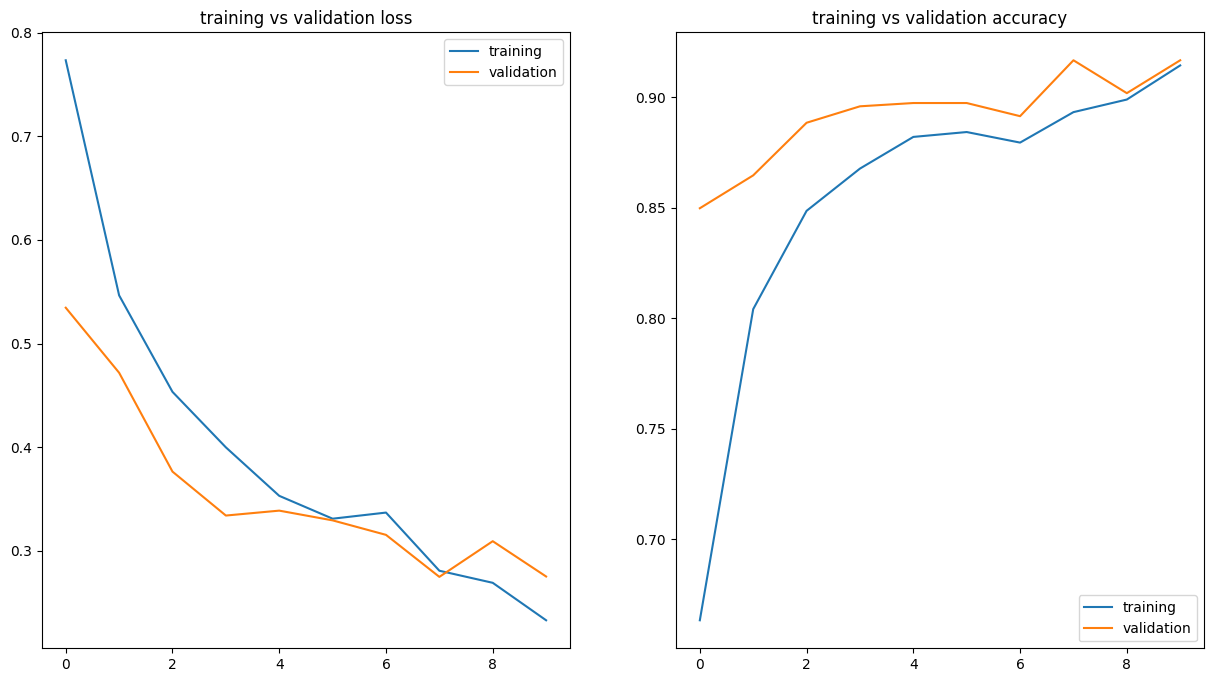

In [24]:
plt.figure(figsize=(15,8))
ax=plt.subplot(1,2,1)
plt.plot(range(len(training_loss)),training_loss,label='training')
plt.plot(range(len(validation_loss)),validation_loss,label='validation')
plt.title('training vs validation loss')
plt.legend(loc = 'upper right')
ax=plt.subplot(1,2,2)
plt.plot(range(len(training_accuracy)),training_accuracy,label='training')
plt.plot(range(len(validation_accuracy)),validation_accuracy,label='validation')
plt.title('training vs validation accuracy')
plt.legend(loc = 'lower right')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 775ms/step


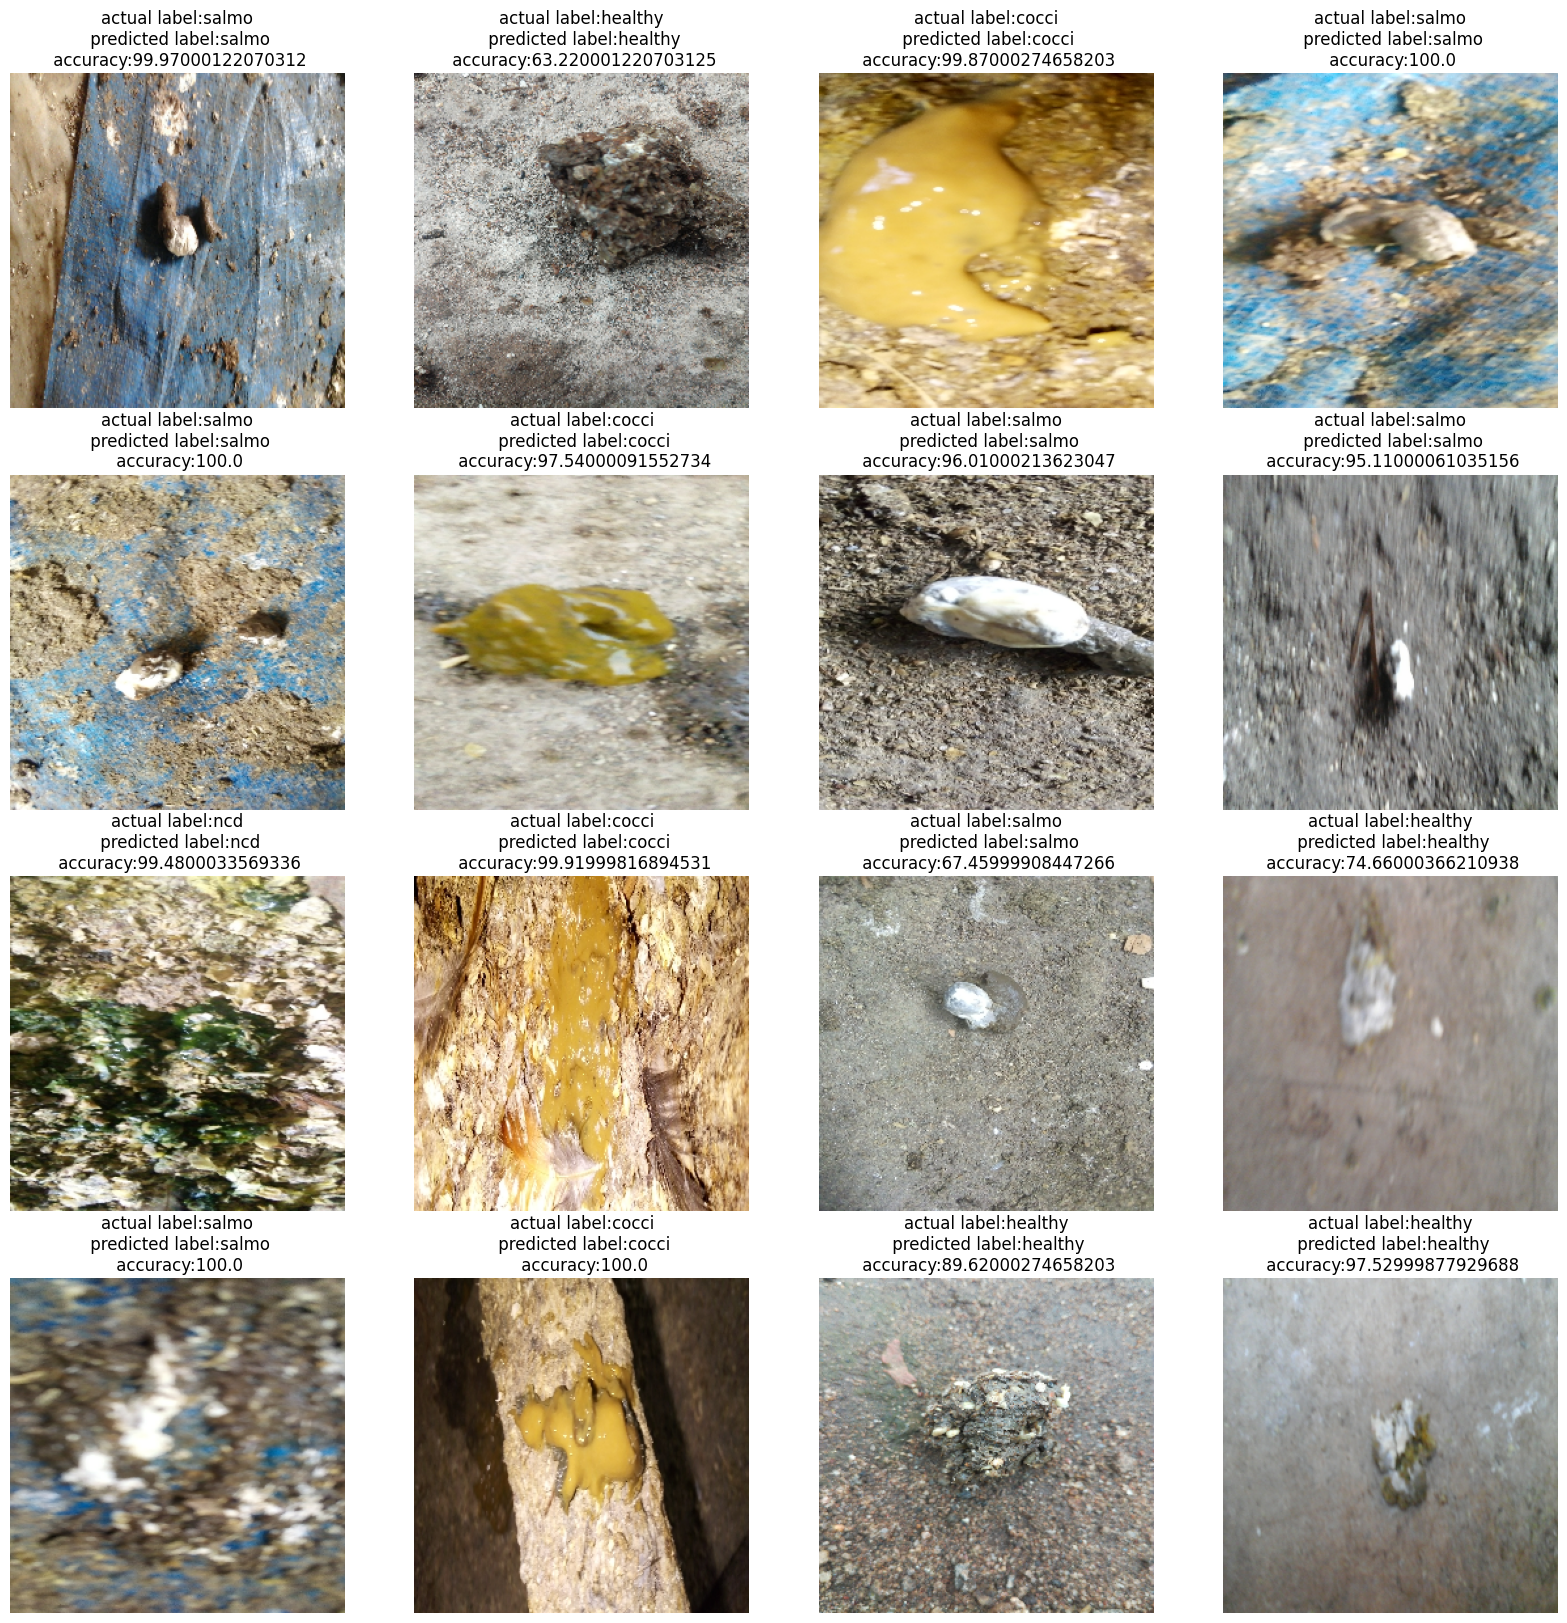

In [25]:
plt.figure(figsize=(20,20))
for img,label in test.take(1):
    batch_prediction=CNN.predict(img)
    for i in range(16):
        ax=plt.subplot(4,4,i+1)
        actual_label=class_names[label[i].numpy()]
        predicted_label=class_names[np.argmax(batch_prediction[i])]
        accuracy=round(np.max(batch_prediction[i])*100,2)
        plt.imshow(img[i].numpy().astype('uint8'))
        plt.title(f'actual label:{actual_label}\n predicted label:{predicted_label}\n accuracy:{accuracy}')
        plt.axis("off")

In [30]:
CNN.save("poultry_disease_model.keras")   # saves in new keras format


In [44]:
from tensorflow.keras.models import load_model

# If saved as .keras
model1 = load_model("poultry_disease_model.keras")

# If saved as .h5
model2 = load_model("poultry_disease_model.h5")


d:\Users\DEBJIT   DAS\Farm Management\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 18 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [45]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# Load your saved model once
model1 = load_model("poultry_disease_model.keras")   # or "poultry_disease_model.h5"

# Define your image size
IMAGE_SIZE = 256  

# Make sure you keep the same class_names you used during training
class_names = ['class1', 'class2', 'class3']  # replace with your dataset class names

def predict_image(img_path, model, class_names, show=True):
    """
    Predicts the class of an image using a trained CNN model.

    Args:
        img_path (str): Path to the image file.
        model (keras.Model): Loaded CNN model.
        class_names (list): List of class names.
        show (bool): If True, displays the image with prediction.

    Returns:
        tuple: (predicted_class_name, confidence_score)
    """
    # Load & preprocess
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0  # normalize

    # Prediction
    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions[0])
    confidence = np.max(predictions[0])

    predicted_label = class_names[predicted_class]

    # Show image
    if show:
        plt.imshow(img)
        plt.title(f"{predicted_label} ({confidence:.2f})")
        plt.axis("off")
        plt.show()

    return predicted_label, confidence


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


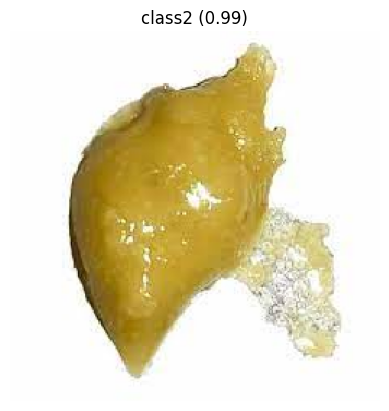

Predicted: class2 | Confidence: 0.9878235


In [47]:
label, conf = predict_image("test_image.jpg", model2, class_names)
print("Predicted:", label, "| Confidence:", conf)
